 # Previsão de Demanda de Rede Farmacêutica

 ## Índice da Análise

 1. Business Problem

    * Starting Context

      * Business Understanding

 2. Starting Phase

    * Requirements

    * Libraries

    * Notebook Settings

 3. Analysis Phase

    * Funções definidas

    * Data Collection

    * Data Cleaning

      * Feature Extraction

    * Data Analysis

      * Descriptive Data Analysis

      * Hypotheses Mindmap

      * Exploratory Data Analysis

 4. Model Phase

    * Funções definidas

    * Feature Engineering

      * Data Preparation

      * Feature Selection

    * Model Building

      * Train-Test Splitting

      * Model Selection

        * Baseline Training

        * Cross Validation Training

        * Models Performance

    * Model Evaluation

      * Model Hyperparameter Fine Tuning

      * Metrics Interpretation

        * Business Metrics

        * Model Metrics

 5. Deployment Phase

    * Visualization and Dashboard

      * Performance Assessment

      * Model Performance

        * Baseline vs Model Performance

        * Model Performance in Business

      * Business Performance Gain

    * API Development

      * Prediction Class

      * API Handler

      * API Tester

    * Web App

      * Frontend

 # 1. Business Problem

 ## Starting Context

 "Uma empresa de distribuidora de medicamentos deseja melhorar suas previsões de demanda de produtos para otimizar seus estoques e reduzir custos operacionais. Atualmente, as previsões são feitas de forma manual e não têm sido eficazes, resultando tanto em excesso de estoque quanto em falta de produtos. Você foi convidado para desenvolver um modelo de previsão de demanda utilizando séries temporais."

 ### Business Understanding

 É possível entender o problema de negócio fazendo apenas 4 perguntas:

 - **Qual a Motivação?** 
    - O Representante da empresa requisitou uma análise de demanda para os próximos 12 meses.

 - **Qual a causa raiz do problema?** 
    - Melhor previsibilidade de demanda para controle de estoque e redução de custos logísticos; dificuldade em determinar a demanda mensal.

 - **Quem é o dono do problema?**
    - O Representante da empresa distribuidora.

 - **Qual o formato da solução de deploy?**

   - *Granularidade*: Previsão de demanda mensal para os próximos 12 meses.

   - *Tipo de Análise*: Predição de séries temporais.

   - *Potenciais Métodos*: ARIMA, SARIMA, SARIMAX com variáveis exógenas (Fourier).

   - *Formato de deploy*: Predição acessada via API Telegram; entrega inicial de 12 meses.

 # 2. Starting Phase

 ## Requirements

 ```

 pandas>=2.0.0

 numpy>=1.24.0

 matplotlib>=3.7.0

 seaborn>=0.12.0

 scipy>=1.10.0

 statsmodels>=0.13.0

 prophet>=1.1.0

 scikit-learn>=1.2.0

 pmdarima>=2.0.0

 ```

 ## Libraries

In [1]:
try:
    import pandas as pd
    import seaborn as sns
    import numpy as np
    from matplotlib import pyplot as plt
    import warnings
    from datetime import datetime, timedelta
    from IPython.display import Image
    from IPython.core.display import HTML
    from statsmodels.tsa.seasonal import seasonal_decompose
    from statsmodels.tsa.stattools import adfuller
    from statsmodels.tsa.statespace.sarimax import SARIMAX
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from scipy.stats import boxcox
    from prophet import Prophet
    from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
    import pmdarima as pm
    warnings.filterwarnings('ignore')
    warnings.simplefilter(action='ignore', category=FutureWarning)
    print("Import successful")
except Exception as e:
    print(f"Error while importing libraries: {e}")


Import successful


In [2]:
Start = datetime.now()


 ## Notebook Settings

In [3]:
def notebook_settings():
    %matplotlib inline
    plt.style.use('bmh')
    plt.rcParams['figure.figsize'] = [30, 15]
    plt.rcParams['font.size'] = 24
    display(HTML('<style>.container { width:100% !important; }</style>'))
    sns.set_theme()

notebook_settings()


 # 3. Analysis Phase

 ### Funções definidas

In [4]:
# Funções de preparação de dados e EDA

def get_column_names(df):
    column_names = pd.Series(df.columns.values)
    columns = pd.DataFrame(column_names)
    columns.columns = ['Columns']
    return columns, column_names

def get_dimensions(df):
    dimensions_1 = pd.Series(df.shape[1])
    dimensions_2 = pd.Series(df.shape[0])
    dimensions = pd.concat([dimensions_1, dimensions_2], axis=1)
    dimensions.columns = ['Columns', 'Rows']
    dimensions = dimensions.T
    dimensions.columns = ['Dimensions']
    return dimensions

def get_dataset_types(df):
    df_types = pd.DataFrame(df.dtypes)
    df_types.reset_index(drop=True, inplace=True)
    df_types.columns = ["Data_Type"]
    df_types["Column"] = pd.Series(df.columns).values
    df_types.set_index("Column", inplace=True)
    return df_types

def get_missing_values(df):
    missing_values = pd.DataFrame(df.isna().sum())
    missing_values.reset_index(drop=True, inplace=True)
    missing_values.columns = ["Missing_Values"]
    missing_values["Column"] = pd.Series(df.columns).values
    missing_values.set_index("Column", inplace=True)
    missing_values.sort_values(by="Missing_Values", ascending=False, inplace=True)
    return missing_values

def get_num_statistics_metrics(df):
    ct1 = pd.DataFrame(df.apply(np.mean)).T
    ct2 = pd.DataFrame(df.apply(np.median)).T
    d1 = pd.DataFrame(df.apply(np.std)).T
    d2 = pd.DataFrame(df.apply(min)).T
    d3 = pd.DataFrame(df.apply(max)).T
    d4 = pd.DataFrame(df.apply(lambda x: x.max() - x.min())).T
    d5 = pd.DataFrame(df.apply(lambda x: x.skew())).T
    d6 = pd.DataFrame(df.apply(lambda x: x.kurtosis())).T
    metrics = pd.concat([d2, d3, d4, ct1, ct2, d1, d5, d6]).T.reset_index()
    metrics.columns = ['Attributes', 'Min', 'Max', 'Range', 'Mean', 'Median', 'Standart Deviation', 'Skew', 'Kurtosis']
    metrics.set_index('Attributes', inplace=True)
    return metrics

In [38]:
# Funções de análise de séries temporais 
def test_stationarity(timeseries, window=12, title='', figsize=(12, 8)): # WINDOW fixada em 12 por conta da sazonalidade mensal
    rolling_mean = timeseries.rolling(window=window).mean()
    rolling_std = timeseries.rolling(window=window).std()
    plt.figure(figsize=figsize)
    plt.title(f'Análise de Estacionariedade: {title}')
    plt.plot(timeseries, color='blue', label='Original')
    plt.plot(rolling_mean, color='red', label=f'Média Móvel (janela={window})')
    plt.plot(rolling_std, color='green', label=f'Desvio Padrão Móvel (janela={window})')
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
    print('Resultados do Teste de Dickey-Fuller:')
    dftest = adfuller(timeseries.dropna(), autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Estatística de Teste', 'p-value', 'Defasagens Usadas', 'Número de Observações Usadas'])
    for key, value in dftest[4].items():
        dfoutput[f'Valor Crítico ({key})'] = value
    print(dfoutput)
    if dftest[1] <= 0.05:
        print("Conclusão: A série é estacionária")
    else:
        print("Conclusão: A série não é estacionária")
    return dfoutput

def plot_acf_pacf(series, figsize=(12, 8), lags=12):
    fig, ax = plt.subplots(2, 1, figsize=figsize)
    plot_acf(series, ax=ax[0], lags=lags)
    ax[0].set_title('Função de Autocorrelação (ACF)')
    plot_pacf(series, ax=ax[1], lags=lags)
    ax[1].set_title('Função de Autocorrelação Parcial (PACF)')
    plt.tight_layout()
    plt.show()

def seasonal_decompose_plot(timeseries, model='additive', period=12, figsize=(14, 10)):
    decomposition = seasonal_decompose(timeseries, model=model, period=period)
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=figsize)
    decomposition.observed.plot(ax=ax1)
    ax1.set_title('Série Original')
    decomposition.trend.plot(ax=ax2)
    ax2.set_title('Tendência')
    decomposition.seasonal.plot(ax=ax3)
    ax3.set_title('Sazonalidade')
    decomposition.resid.plot(ax=ax4)
    ax4.set_title('Resíduos')
    plt.tight_layout()
    plt.show()


 ## Data Collection

In [6]:
try:
    df_raw = pd.read_csv('./df_case_1_-_500_linhas.csv')
    print("Dataset carregado com sucesso")
except Exception as e:
    print(f"Erro ao carregar: {e}")


Dataset carregado com sucesso


 ## Data Cleaning

In [7]:
df_raw.head()

,CATEGORIA,PRODUTO,FORNECEDOR,COMPRADOR,CENTROS DE DISTRIBUICAO,DESCRICAO,QTD DE CAIXAS,MAR22,ABR22,MAI22,...,JUN23,JUL23,AGO23,SET23,OUT23,NOV23,DEZ23,JAN24,FEV24,MAR24
0,A,A,A,A,A,A,109,356,374,408,...,404,350,466,290,476,524,273,199,313,197
1,A,A,A,A,B,B,70,994,723,1310,...,1897,1840,2427,1655,1669,1970,1700,1895,1385,2243
2,B,B,B,B,C,C,123,74,65,71,...,144,57,69,165,129,153,149,145,125,132
3,B,C,C,C,D,D,196,520,466,603,...,496,568,443,304,408,372,315,447,610,776
4,A,D,A,A,E,E,99,37,1,78,...,75,60,85,13,45,24,8,64,79,96


#### Seleção do Produto e Centro de Distribuição para Análise

Dado o dataset completo é necessário escolher um produto específico e seu respectivo centro para realizar a previsão de demanda dos próximos 12 meses, conforme o desafio técnico. Previsão essa que pode e deve ser expandida para cada produto posteriormente, sendo essa análise a primeira prova de conceito, dado que por enquanto, foi pedido a análise de apenas um produto.

In [8]:
date_columns = [col for col in df_raw.columns if col not in 
                ['CATEGORIA', 'PRODUTO', 'FORNECEDOR', 'COMPRADOR', 
                'CENTROS DE DISTRIBUICAO', 'DESCRICAO', 'QTD DE CAIXAS']]

df_all_melted = pd.melt(df_raw, 
                        id_vars=['PRODUTO', 'CENTROS DE DISTRIBUICAO'], 
                        value_vars=date_columns,
                        var_name='date_str', 
                        value_name='sales')

df_all_melted['date'] = pd.to_datetime(df_all_melted['date_str'], format='%b%y', errors='coerce')

df_all_melted = df_all_melted.dropna(subset=['date'])
df_all_melted = df_all_melted.sort_values(['PRODUTO', 'CENTROS DE DISTRIBUICAO', 'date'])
df_all_melted.head()

,PRODUTO,CENTROS DE DISTRIBUICAO,date_str,sales,date
0,A,A,MAR22,356,2022-03-01
294,A,A,MAR22,283,2022-03-01
337,A,A,MAR22,29,2022-03-01
1500,A,A,JUN22,453,2022-06-01
1794,A,A,JUN22,776,2022-06-01


In [9]:
df_all_melted['date'].unique()

array(['2022-03-01T00:00:00.000000000', '2022-06-01T00:00:00.000000000',
       '2022-07-01T00:00:00.000000000', '2022-11-01T00:00:00.000000000',
       '2023-01-01T00:00:00.000000000', '2023-03-01T00:00:00.000000000',
       '2023-06-01T00:00:00.000000000', '2023-07-01T00:00:00.000000000',
       '2023-11-01T00:00:00.000000000', '2024-01-01T00:00:00.000000000',
       '2024-03-01T00:00:00.000000000'], dtype='datetime64[ns]')

O data frame apenas contém datas com o primeiro dia de cada mês, o que confirma a intenção de representar os dados apenas de forma mensal. Não temos nenhum dia interno de cada mês, apenas o primeiro para o formato de data não quebrar.

In [10]:
all_products = df_all_melted['PRODUTO'].unique()
all_products

array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
       'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z'],
      dtype=object)

In [11]:
df_a_melted = df_all_melted[df_all_melted['PRODUTO'] == 'A'].copy()

In [12]:
centers_for_a = df_a_melted['CENTROS DE DISTRIBUICAO'].unique()
print(f"\nDistribution centers for Product A: {centers_for_a}")


Distribution centers for Product A: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'J' 'L' 'N' 'O' 'S' 'U']


Temos muitos produtos e muitos centros, vamos checar cada produtoXcentro para descobrir qual tem a maior quantidade de dados completos, para que possamos fazer a previsão de demanda.
Para isso vamos montar uma lista de meses entre máximo e mínimo do que aparecem no dataframe, e então checar por produto e por cada centro, quantos meses temos de dados completos e quantos meses temos de dados faltantes.

In [13]:
product_center_missing = {}

all_products = df_all_melted['PRODUTO'].unique()

for product in all_products:
    
    df_product = df_all_melted[df_all_melted['PRODUTO'] == product]
    centers = df_product['CENTROS DE DISTRIBUICAO'].unique()
    
    for center in centers:
        
        df_combo = df_product[df_product['CENTROS DE DISTRIBUICAO'] == center]
        
        df_grouped = df_combo.groupby('date')['sales'].sum().reset_index()
        
        min_date = df_grouped['date'].min()
        max_date = df_grouped['date'].max()
        
        expected_dates = pd.date_range(start=min_date, end=max_date, freq='MS') # freq. meaning 1st (FIRST) day of each month, eg: 2021-01-01, 2021-02-01, etc.
        # Aqui estamos seguindo o mesmo princípio do que vimos no começo, apenas o dia 1 de cada mês para representar o próprio.
        actual_dates = set(df_grouped['date']) # Fechamos um grupo de datas únicas
        missing_count = sum(1 for date in expected_dates if date not in actual_dates)
        
        portuguese_months = {   1: 'JAN', 2: 'FEV', 3: 'MAR', 4: 'ABR', 5: 'MAI', 6: 'JUN',
                                7: 'JUL', 8: 'AGO', 9: 'SET', 10: 'OUT', 11: 'NOV', 12: 'DEZ'
                            }
        
        key = (product, center)
        product_center_missing[key] = { 'missing_count': missing_count,
                                        'total_months': len(expected_dates),
                                        'missing_months': [f"{portuguese_months[month_missing.month]}/{month_missing.year}" for month_missing in expected_dates if month_missing not in actual_dates],
                                        'min_date': min_date,
                                        'max_date': max_date
                                    }

missing_df = pd.DataFrame([{'product': prod_center[0],
                            'center': prod_center[1],
                            'missing_count': info['missing_count'],
                            'missing_months': info['missing_months'],
                            'total_months': info['total_months'],
                            'missing_percentage': (info['missing_count'] / info['total_months']) * 100 if info['total_months'] > 0 else 100,
                            'min_date': info['min_date'],
                            'max_date': info['max_date']
                        }
                        for prod_center, info in product_center_missing.items()
                    ])

# Sort by completely missing months (ascending)
missing_df = missing_df.sort_values('missing_months')

# Display the top 10 product-center combinations with the least missing months
top_10 = missing_df.head(10)
print("\nTop 10 product-center combinations with least missing months:")
display(top_10[['product', 'center', 'missing_months', 'total_months', 'missing_count', 'missing_percentage']])

# Get the best combination
best_combo = missing_df.iloc[0]
print(f"\nBest combination: Product {best_combo['product']}, Center {best_combo['center']} with {best_combo['missing_months']} missing months out of {best_combo['total_months']} total months ({best_combo['missing_percentage']:.2f}%)")

best_product = best_combo['product']
best_center = best_combo['center']

df_best_combo = df_all_melted[(df_all_melted['PRODUTO'] == best_product) & 
                              (df_all_melted['CENTROS DE DISTRIBUICAO'] == best_center)].copy()


Top 10 product-center combinations with least missing months:


,product,center,missing_months,total_months,missing_count,missing_percentage
0,A,A,"[ABR/2022, MAI/2022, AGO/2022, SET/2022, OUT/2...",25,14,56.0
214,P,V,"[ABR/2022, MAI/2022, AGO/2022, SET/2022, OUT/2...",25,14,56.0
213,P,U,"[ABR/2022, MAI/2022, AGO/2022, SET/2022, OUT/2...",25,14,56.0
212,P,S,"[ABR/2022, MAI/2022, AGO/2022, SET/2022, OUT/2...",25,14,56.0
211,P,R,"[ABR/2022, MAI/2022, AGO/2022, SET/2022, OUT/2...",25,14,56.0
210,P,Q,"[ABR/2022, MAI/2022, AGO/2022, SET/2022, OUT/2...",25,14,56.0
209,P,N,"[ABR/2022, MAI/2022, AGO/2022, SET/2022, OUT/2...",25,14,56.0
208,P,M,"[ABR/2022, MAI/2022, AGO/2022, SET/2022, OUT/2...",25,14,56.0
207,P,K,"[ABR/2022, MAI/2022, AGO/2022, SET/2022, OUT/2...",25,14,56.0
206,P,J,"[ABR/2022, MAI/2022, AGO/2022, SET/2022, OUT/2...",25,14,56.0



Best combination: Product A, Center A with ['ABR/2022', 'MAI/2022', 'AGO/2022', 'SET/2022', 'OUT/2022', 'DEZ/2022', 'FEV/2023', 'ABR/2023', 'MAI/2023', 'AGO/2023', 'SET/2023', 'OUT/2023', 'DEZ/2023', 'FEV/2024'] missing months out of 25 total months (56.00%)


Pelo resultado da tabela, escolhi o Produto A por conta de todos estarem com a mesma quantidade de meses faltantes.

Agora que temos o produto, vamos checar qual centro de distribuicao tem a distribuicao mais interessante para fazer a previsão de demanda.

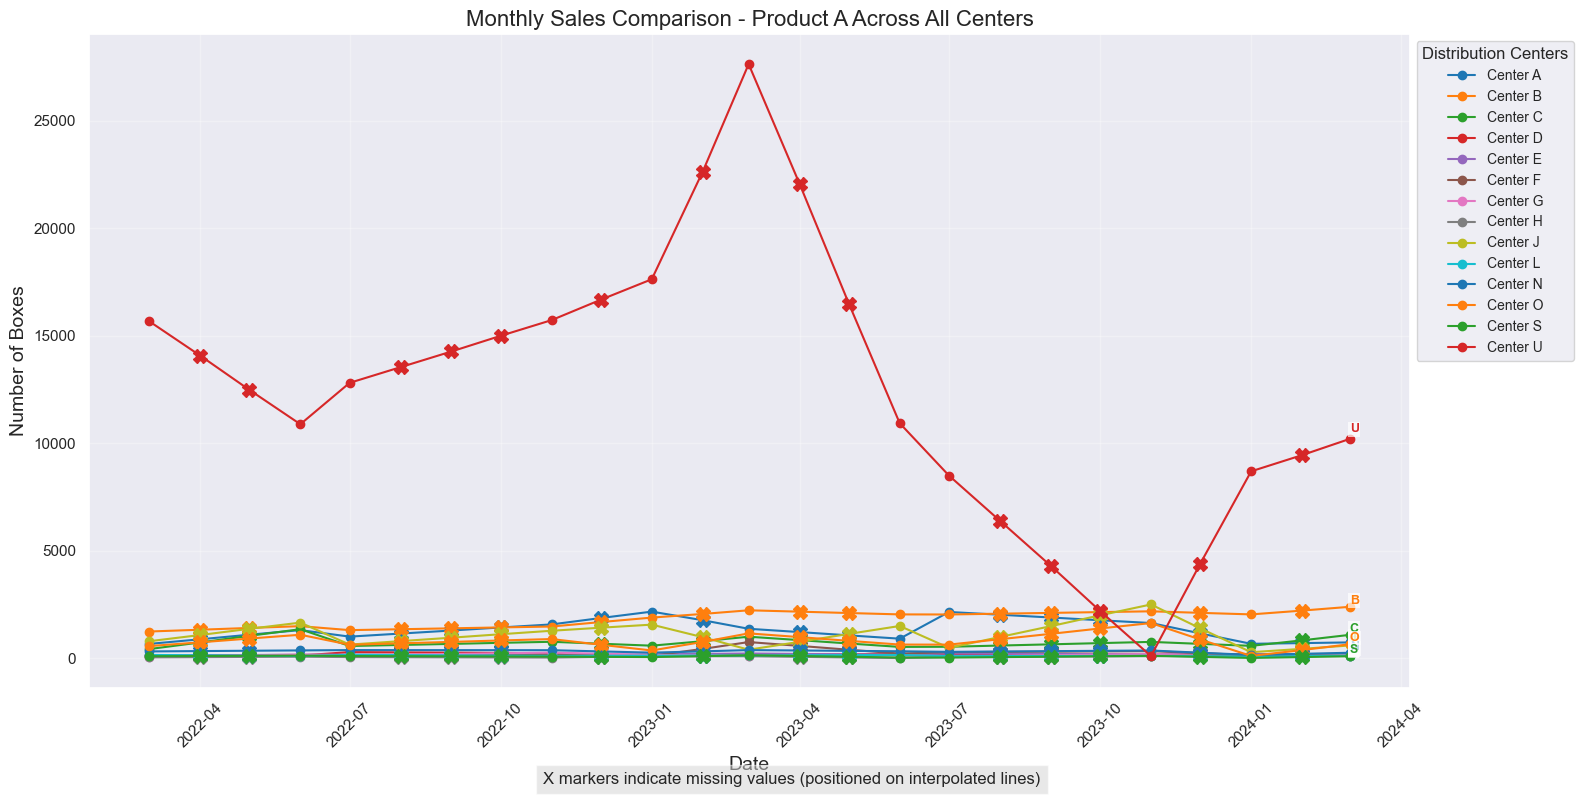

In [14]:
plt.figure(figsize=(16, 8))

colors = plt.cm.tab10.colors  # This gives 10 distinct colors

for i, center in enumerate(centers_for_a):
    color = colors[i % len(colors)]
    
    df_center = df_a_melted[df_a_melted['CENTROS DE DISTRIBUICAO'] == center]
    df_center_grouped = df_center.groupby('date')['sales'].sum().reset_index()
    
    min_date = df_center_grouped['date'].min()
    max_date = df_center_grouped['date'].max()
    
    expected_dates = pd.date_range(start=min_date, end=max_date, freq='MS')
    
    full_date_df = pd.DataFrame({'date': expected_dates})
    full_date_df = full_date_df.merge(df_center_grouped, on='date', how='left')
    
    full_date_df['sales_interpolated'] = full_date_df['sales'].interpolate(method='linear')
    full_date_df['sales_interpolated'] = full_date_df['sales_interpolated'].fillna(method='bfill').fillna(method='ffill')
    
    # Identify which points are observed vs interpolated
    full_date_df['is_interpolated'] = full_date_df['sales'].isna()
    
    # Plot the complete interpolated line
    line, = plt.plot(full_date_df['date'], full_date_df['sales_interpolated'], 
            marker='o', linestyle='-', color=color, 
            label=f'Center {center}')
    
    # Add label directly to the end of the line
    last_date = full_date_df['date'].iloc[-1]
    last_value = full_date_df['sales_interpolated'].iloc[-1]
    
    # Define the vertical offset based on the data range
    vertical_offset = 0.3 * max(full_date_df['sales_interpolated']) * 0.02  # 2% of the max value
    
    plt.text(last_date, last_value + vertical_offset, center, fontsize=9, 
            color=color, fontweight='bold', 
            ha='left', va='bottom',
            bbox=dict(facecolor='white', alpha=0.7, pad=1, edgecolor='none'))
        
    # Overlay X markers at the interpolated points
    interpolated_points = full_date_df[full_date_df['is_interpolated']]
    
    if not interpolated_points.empty:
        plt.plot(interpolated_points['date'], interpolated_points['sales_interpolated'], 
                'X', color=color, markersize=10)

plt.title('Monthly Sales Comparison - Product A Across All Centers', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Boxes', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# We still keep the legend, but now it's optional as we have labels on the lines
plt.legend(title='Distribution Centers', loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)

plt.figtext(0.5, 0.01, 'X markers indicate missing values (positioned on interpolated lines)', 
           ha='center', fontsize=12, bbox={"facecolor":"lightgrey", "alpha":0.5, "pad":5})

plt.tight_layout()
plt.show()

Agora com a primeira análise concluída, a escolha fica clara

Após inspeção visual e análise dos dados, optei pelo **Produto A, Centro U**, que se deu pois:

- **Completude dos Dados**: Todos os produtos e centros de distribuição possuem dados incompletos, com valores faltantes nos mesmos meses. Imaginei que algum deles fosse apresentar uma completude maior, mas isso não ocorreu. 



Todos os produtos tem a mesma quantidade de valores faltantes, no entanto, na visualização gráfica, o Produto A no Centro U apresenta uma distribuição com valores mais significativos de vendas, o que pode ser um indicativo de sazonalidade, enquanto todos os outros centros com o produto A apresentam vendas mais baixas e sem sazonalidade aparente, o que pode dificultar a modelagem nessa fase.

Novamente, essa análise teria de ser refeita com todos os produtos X todos os centros, para adaptar os resultados a cada tipo de produto farmacêutico, que evidentemente devem ter demandas diferentes.

In [15]:
df_AxU = df_all_melted[(df_all_melted['PRODUTO'] == 'A') & 
                       (df_all_melted['CENTROS DE DISTRIBUICAO'] == 'U')].copy()

df_AxU_grouped = df_AxU.groupby('date')['sales'].sum().reset_index()

min_date_a_a = df_AxU_grouped['date'].min()
max_date_a_a = df_AxU_grouped['date'].max()
expected_dates_a_a = pd.date_range(start=min_date_a_a, end=max_date_a_a, freq='MS')

df_ts = pd.DataFrame({'date': expected_dates_a_a})
df_ts = df_ts.merge(df_AxU_grouped, on='date', how='left')

missing_before = df_ts['sales'].isna().sum()
print(f"Missing values before filling: {missing_before} out of {len(df_ts)} rows ({missing_before/len(df_ts)*100:.1f}%)")


Missing values before filling: 14 out of 25 rows (56.0%)


Agora para os valores faltantes das caixas (sales), vamos preencher com uma interpolação linear, e os casos faltantes, vamos usar um bfill (preencher com o valor anterior) para não perdermos a sazonalidade dos dados.

In [16]:
df_ts['sales_interpolated'] = df_ts['sales'].interpolate(method='linear')

# Handle edge cases if any values remain missing
df_ts['sales_interpolated'] = df_ts['sales_interpolated'].fillna(method='bfill').fillna(method='ffill')

# Count missing values after filling
missing_after = df_ts['sales_interpolated'].isna().sum()
print(f"Missing values after filling: {missing_after}")


Missing values after filling: 0


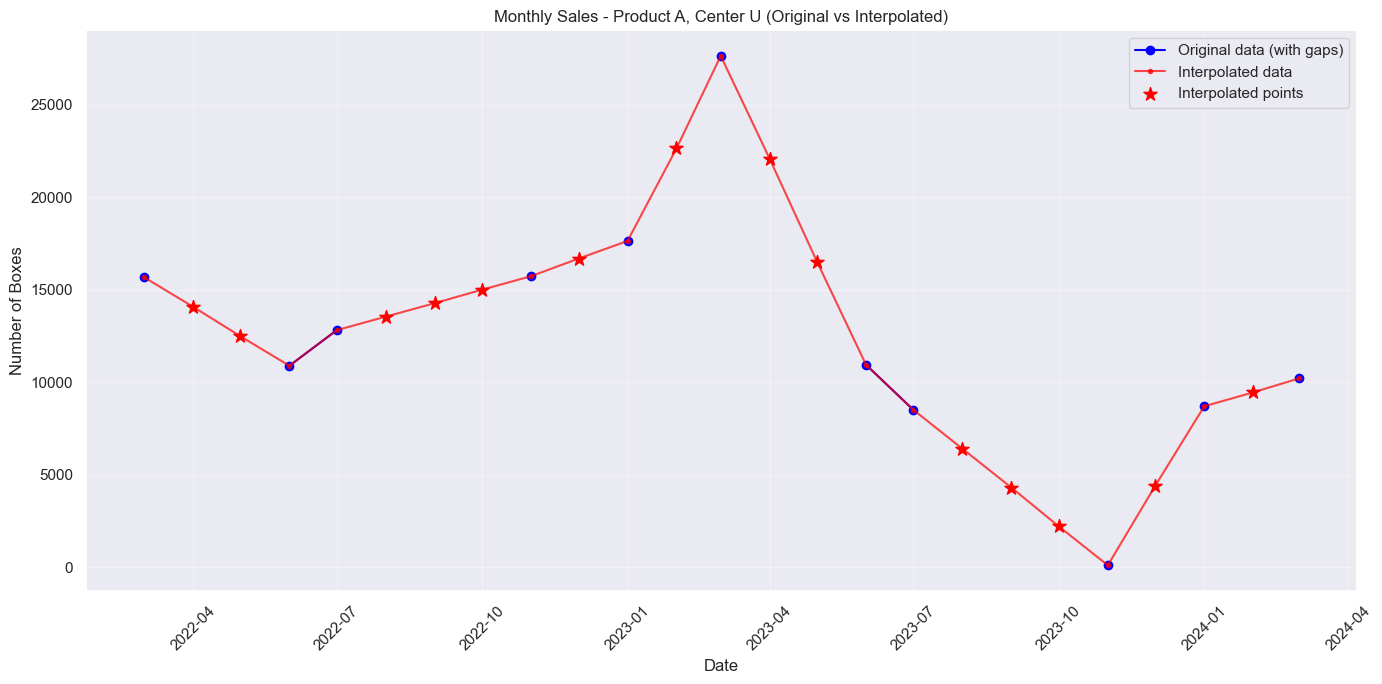

In [17]:

# Create a column to flag which values were interpolated
df_ts['is_interpolated'] = df_ts['sales'].isna()

# Visualize original vs interpolated data
plt.figure(figsize=(14, 7))
plt.plot(df_ts['date'], df_ts['sales'], 'o-', label='Original data (with gaps)', color='blue')
plt.plot(df_ts['date'], df_ts['sales_interpolated'], '.-', label='Interpolated data', color='red', alpha=0.7)

# Highlight interpolated points
interpolated_points = df_ts[df_ts['is_interpolated']]
plt.scatter(interpolated_points['date'], interpolated_points['sales_interpolated'], 
           color='red', s=100, marker='*', label='Interpolated points')

plt.title('Monthly Sales - Product A, Center U (Original vs Interpolated)')
plt.xlabel('Date')
plt.ylabel('Number of Boxes')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


Renomeando a coluna 'sales_interpolated' para 'sales' e removendo a coluna 'sales' original.

In [18]:
# Keep only necessary columns for the final dataset
df_ts = df_ts[['date', 'sales_interpolated']].rename(columns={'sales_interpolated': 'sales'})

In [20]:
print("\nFinal time series dataset with interpolated values:")
df_ts.set_index('date', inplace=True)
display(df_ts.head(50))
display(df_ts.info())


Final time series dataset with interpolated values:


,sales
date,
2022-03-01,15675.000000
2022-04-01,14079.000000
2022-05-01,12483.000000
2022-06-01,10887.000000
2022-07-01,12812.000000
2022-08-01,13541.500000
2022-09-01,14271.000000
2022-10-01,15000.500000
2022-11-01,15730.000000


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 25 entries, 2022-03-01 to 2024-03-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sales   25 non-null     float64
dtypes: float64(1)
memory usage: 400.0 bytes


None

 ### Feature Extraction

In [21]:
df_ts['sales'] = df_ts['sales'].interpolate()
print(f"Valores faltantes após interpolação: {df_ts['sales'].isnull().sum()}")

Valores faltantes após interpolação: 0


 ## Data Analysis

 ### Descriptive Data Analysis

In [22]:
display(get_dimensions(df_ts))
display(get_dataset_types(df_ts))
display(get_missing_values(df_ts))
display(get_num_statistics_metrics(df_ts[['sales']]))


,Dimensions
Columns,1
Rows,25


,Data_Type
Column,
sales,float64


,Missing_Values
Column,
sales,0


,Min,Max,Range,Mean,Median,Standart Deviation,Skew,Kurtosis
Attributes,,,,,,,,
sales,100.0,27640.0,27540.0,12512.52,12812.0,6315.37118,0.209239,0.264609


 ### Hypotheses Mindmap

 - H1: A demanda tem tendência crescente ao longo do tempo.

 - H2: Existe sazonalidade anual na demanda.
    - H2.1: Nos meses de inverno, a demanda é maior. (Hemisfério Norte ou Sul?)

 - H3: Anomalias afetam os picos de demanda.

 ### Exploratory Data Analysis

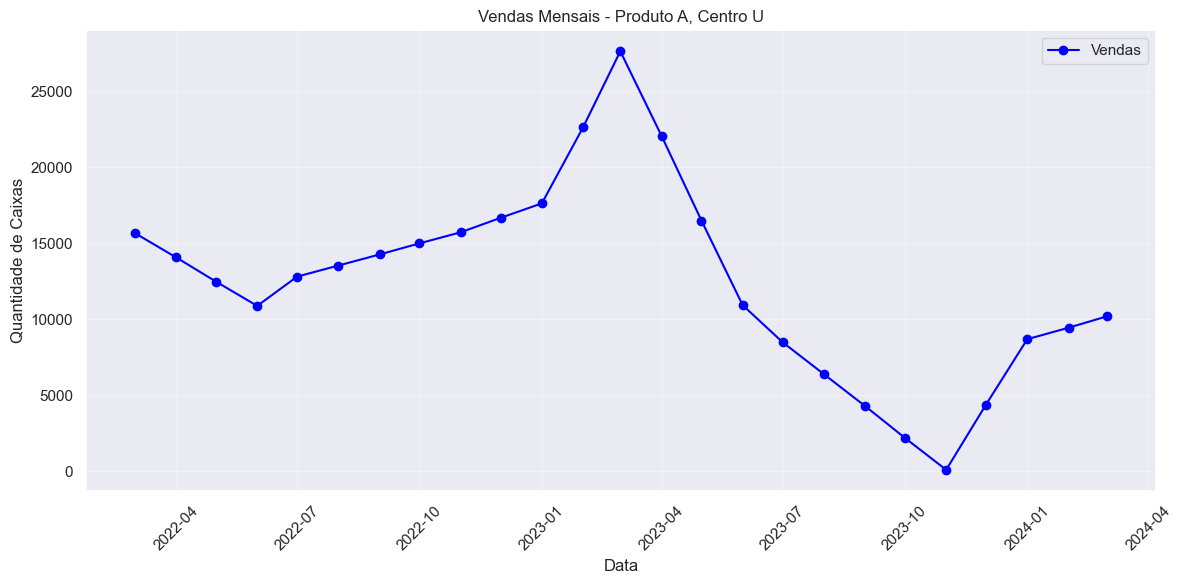

In [24]:
plt.figure(figsize=(12, 6))
plt.plot(df_ts.index, df_ts['sales'], marker='o', label='Vendas', color='blue')
plt.title('Vendas Mensais - Produto A, Centro U')
plt.xlabel('Data')
plt.ylabel('Quantidade de Caixas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

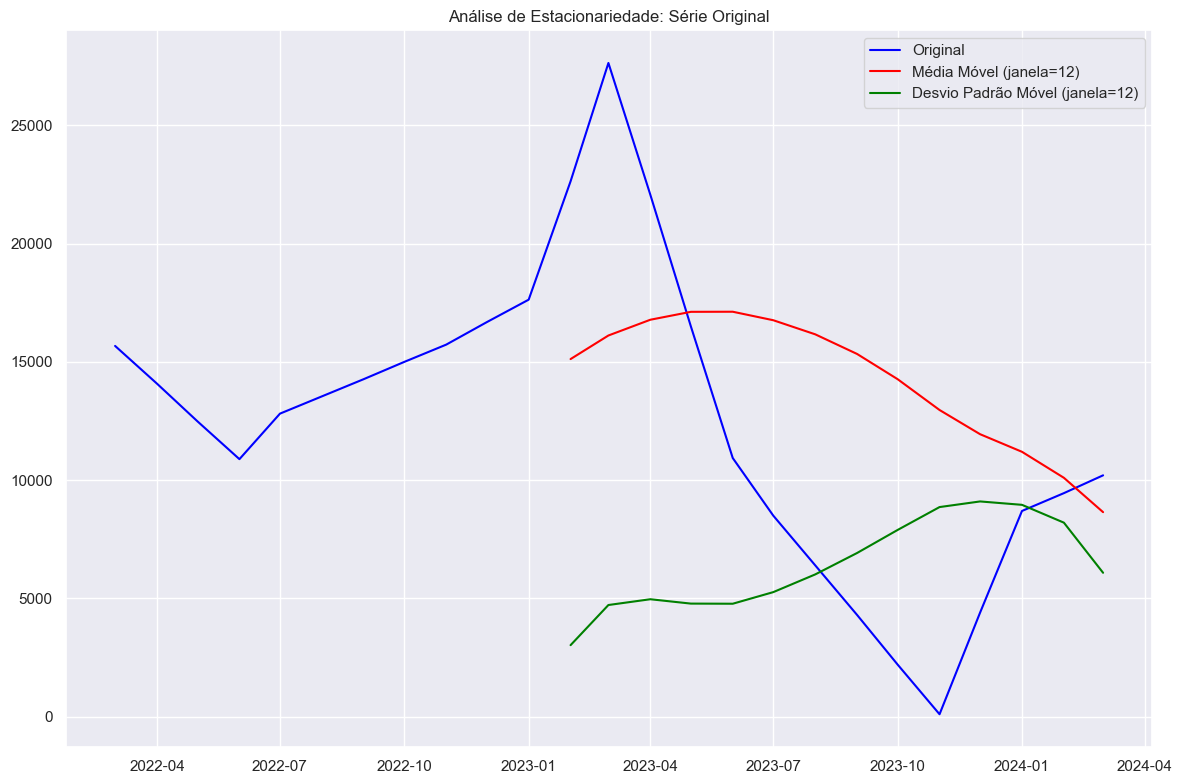

Resultados do Teste de Dickey-Fuller:
Estatística de Teste            -2.149199
p-value                          0.225197
Defasagens Usadas                1.000000
Número de Observações Usadas    23.000000
Valor Crítico (1%)              -3.752928
Valor Crítico (5%)              -2.998500
Valor Crítico (10%)             -2.638967
dtype: float64
Conclusão: A série não é estacionária


Estatística de Teste            -2.149199
p-value                          0.225197
Defasagens Usadas                1.000000
Número de Observações Usadas    23.000000
Valor Crítico (1%)              -3.752928
Valor Crítico (5%)              -2.998500
Valor Crítico (10%)             -2.638967
dtype: float64

In [27]:
# Estacionaridade
test_stationarity(df_ts['sales'], title='Série Original')

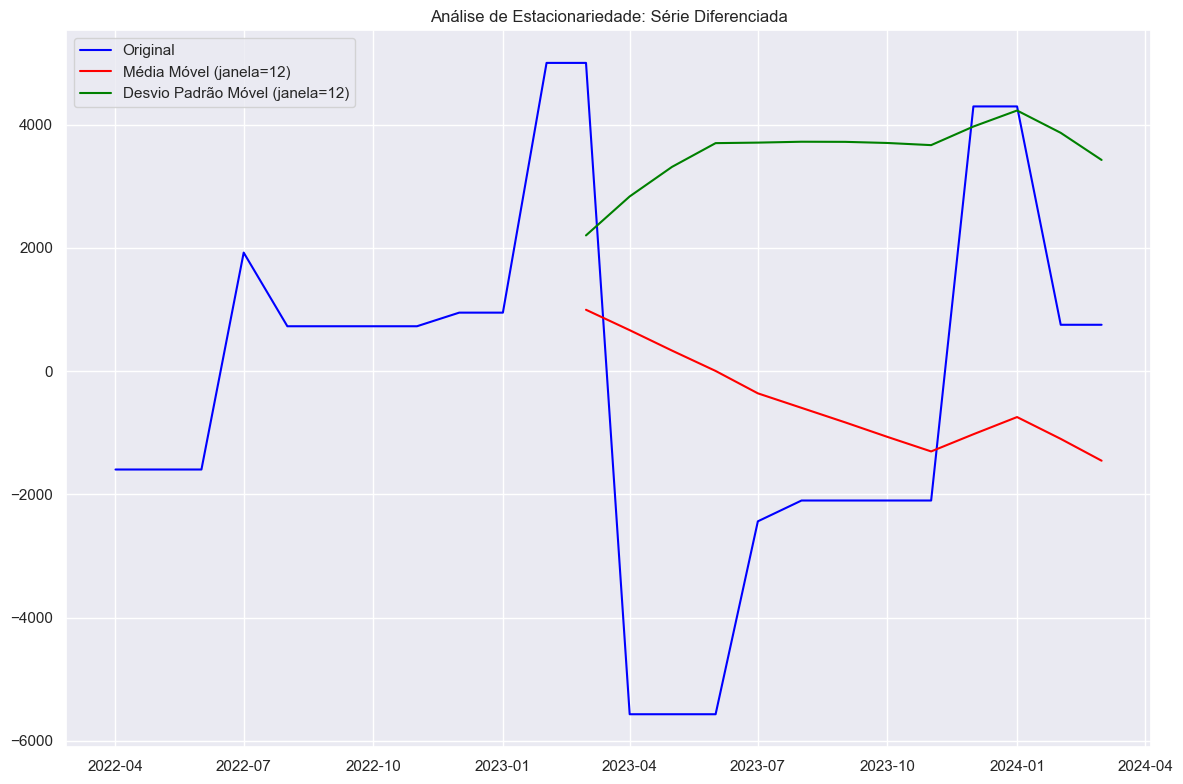

Resultados do Teste de Dickey-Fuller:
Estatística de Teste            -2.559672
p-value                          0.101622
Defasagens Usadas                0.000000
Número de Observações Usadas    23.000000
Valor Crítico (1%)              -3.752928
Valor Crítico (5%)              -2.998500
Valor Crítico (10%)             -2.638967
dtype: float64
Conclusão: A série não é estacionária


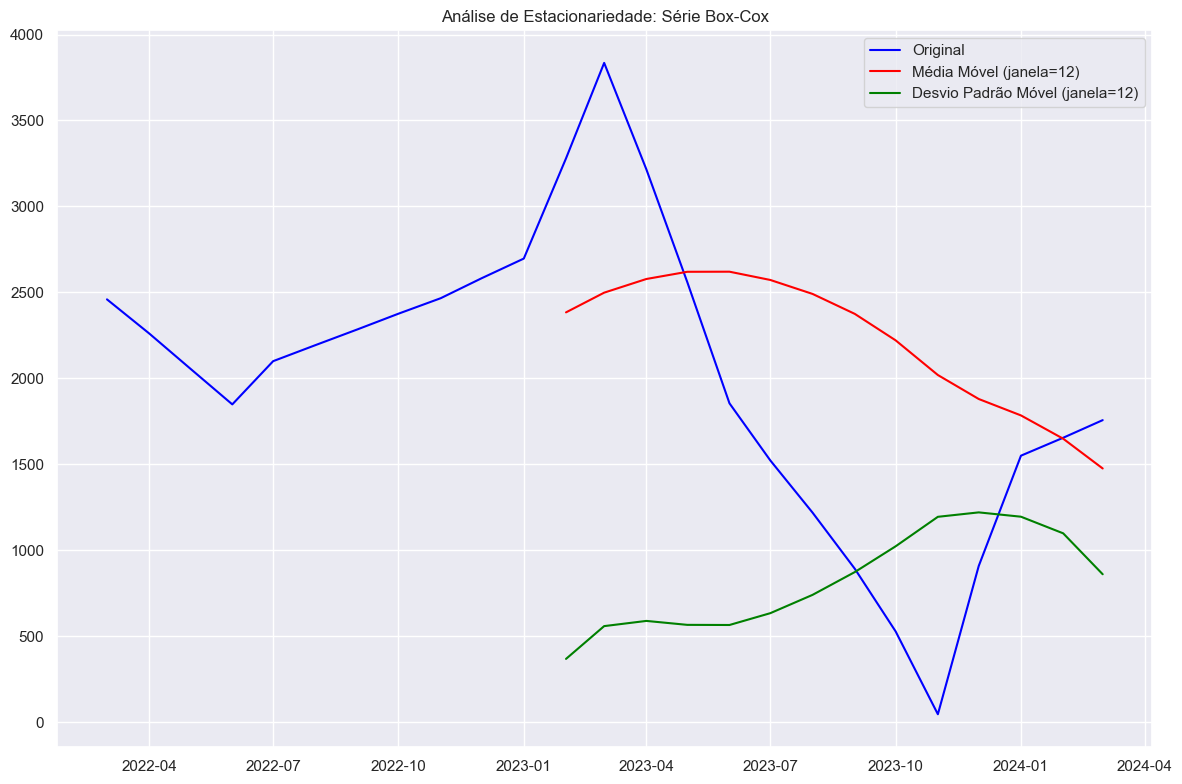

Resultados do Teste de Dickey-Fuller:
Estatística de Teste            -2.032019
p-value                          0.272713
Defasagens Usadas                1.000000
Número de Observações Usadas    23.000000
Valor Crítico (1%)              -3.752928
Valor Crítico (5%)              -2.998500
Valor Crítico (10%)             -2.638967
dtype: float64
Conclusão: A série não é estacionária


Estatística de Teste            -2.032019
p-value                          0.272713
Defasagens Usadas                1.000000
Número de Observações Usadas    23.000000
Valor Crítico (1%)              -3.752928
Valor Crítico (5%)              -2.998500
Valor Crítico (10%)             -2.638967
dtype: float64

In [28]:
# Transformação (diferenciação e Box-Cox)
df_ts['sales_diff'] = df_ts['sales'].diff().dropna()
df_ts['sales_boxcox'], lam = boxcox(df_ts['sales'])
test_stationarity(df_ts['sales_diff'], title='Série Diferenciada')
test_stationarity(df_ts['sales_boxcox'], title='Série Box-Cox')

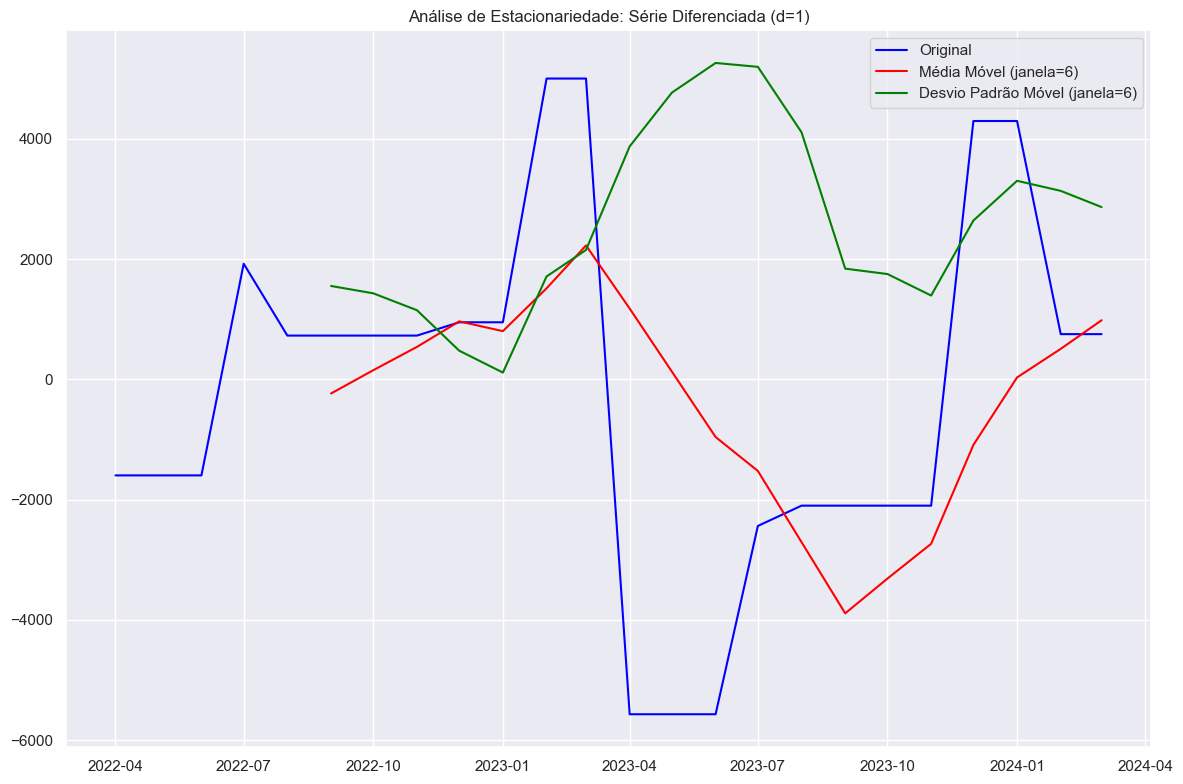

Resultados do Teste de Dickey-Fuller:
Estatística de Teste            -2.559672
p-value                          0.101622
Defasagens Usadas                0.000000
Número de Observações Usadas    23.000000
Valor Crítico (1%)              -3.752928
Valor Crítico (5%)              -2.998500
Valor Crítico (10%)             -2.638967
dtype: float64
Conclusão: A série não é estacionária


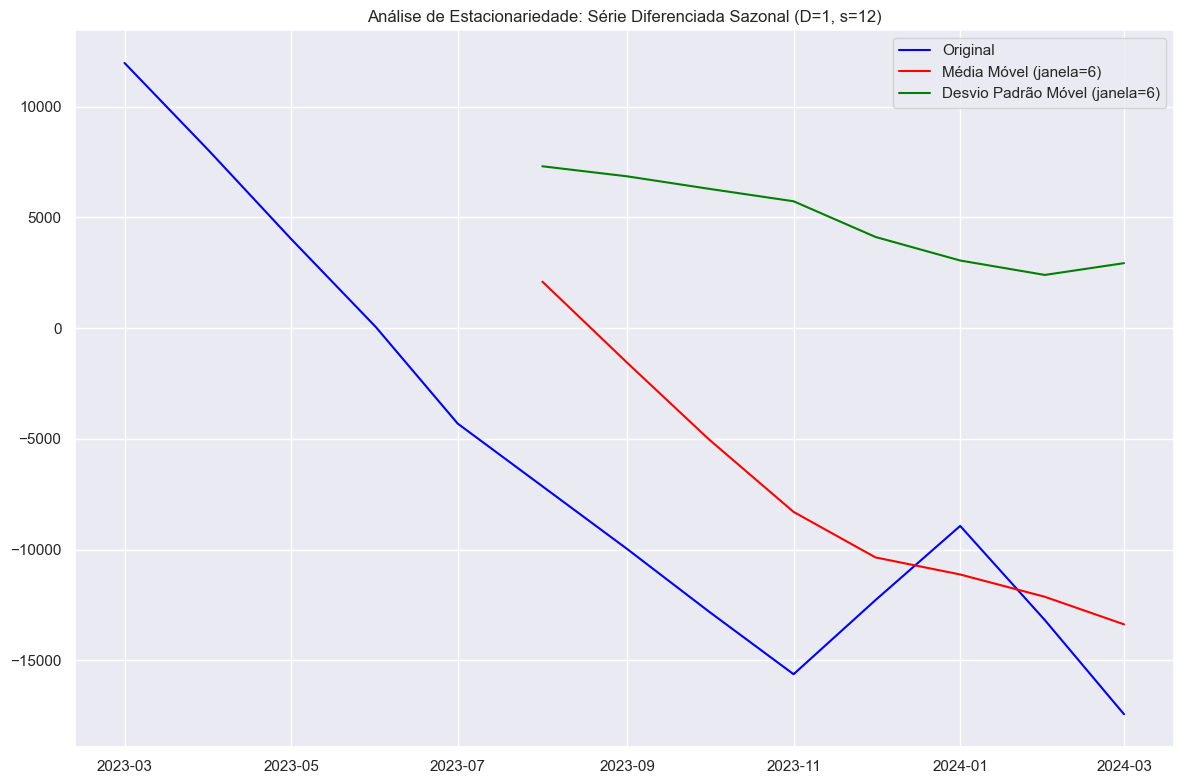

Resultados do Teste de Dickey-Fuller:
Estatística de Teste           -2.971053
p-value                         0.037688
Defasagens Usadas               4.000000
Número de Observações Usadas    8.000000
Valor Crítico (1%)             -4.665186
Valor Crítico (5%)             -3.367187
Valor Crítico (10%)            -2.802961
dtype: float64
Conclusão: A série é estacionária


Estatística de Teste           -2.971053
p-value                         0.037688
Defasagens Usadas               4.000000
Número de Observações Usadas    8.000000
Valor Crítico (1%)             -4.665186
Valor Crítico (5%)             -3.367187
Valor Crítico (10%)            -2.802961
dtype: float64

In [30]:
# Re-check original differencing (d=1 only, skip seasonal for now)
df_ts['sales_diff'] = df_ts['sales'].diff().dropna()  # d=1
test_stationarity(df_ts['sales_diff'], window=6, title='Série Diferenciada (d=1)')

# If still non-stationary, try seasonal differencing with smaller window
df_ts['sales_diff_seasonal'] = df_ts['sales'].diff(12).dropna()  # D=1, s=12
test_stationarity(df_ts['sales_diff_seasonal'], window=6, title='Série Diferenciada Sazonal (D=1, s=12)')

#### Análise de Estacionaridade

A análise de estacionaridade é um passo crucial para modelagem de séries temporais, pois modelos como ARIMA e SARIMA assumem que os dados são estacionários, ou seja, possuem média e variância constantes ao longo do tempo, sem tendências ou sazonalidades significativas. Para a série temporal das vendas mensais do **Produto A, Centro U**, com 25 meses de dados (Março/2022 a Março/2024), interpolados linearmente para preencher 56% de valores ausentes, realizamos uma avaliação detalhada da estacionaridade utilizando o teste de Dickey-Fuller Aumentado (ADF) e visualizações gráficas via função `test_stationarity`.

##### 1. Série Original
A série original (`df_ts['sales']`) foi inicialmente analisada para verificar sua estacionaridade. A visualização gráfica mostrou uma clara tendência crescente até Março/2023, com um pico de cerca de 27.000 caixas, seguido por uma queda acentuada até valores próximos de 100 caixas em Novembro/2023, e uma recuperação parcial até Março/2024 (10.000 caixas). O teste ADF apresentou:

- **Estatística de Teste**: -2.149199
- **p-value**: 0.225197
- **Conclusão**: Como o p-value é maior que 0.05, rejeitamos a hipótese nula de estacionaridade, confirmando que a série é não-estacionária. A presença de uma tendência clara (crescimento até 2023) e possível sazonalidade anual (picos em Janeiro) justifica a necessidade de transformações.

##### 2. Diferenciação Simples (d=1)
Para remover a tendência, aplicamos uma diferenciação simples (`df_ts['sales_diff'] = df_ts['sales'].diff().dropna()`), resultando em 24 observações (Mar/22 a Mar/24, menos 1 ponto). A visualização gráfica mostrou variações mensais entre aproximadamente -6.000 e 4.000 caixas, com uma média próxima de zero, mas ainda com flutuações indicando possível sazonalidade residual. O teste ADF indicou:

- **Estatística de Teste**: -2.559672
- **p-value**: 0.101622
- **Conclusão**: Com p-value > 0.05, a série permanece não-estacionária. Embora a diferenciação tenha reduzido a tendência (de 0.22 para 0.10), a sazonalidade anual (esperada para s=12) ou variações residuais mantêm a não-estacionaridade. Isso sugere a necessidade de diferenciação sazonal.

##### 3. Diferenciação Sazonal (D=1, s=12)
Para abordar a sazonalidade anual, aplicamos uma diferenciação sazonal de ordem 1 com período s=12 (`df_ts['sales_diff_seasonal'] = df_ts['sales'].diff(12).dropna()`), resultando em 13 observações (Mar/23 a Mar/24, menos 12 pontos). A visualização gráfica mostrou variações entre -15.000 e 10.000 caixas, com média próxima de zero e variância aparentemente estável. O teste ADF revelou:

- **Estatística de Teste**: -2.971053
- **p-value**: 0.037688
- **Conclusão**: Com p-value < 0.05 enfim rejeitamos a hipótese nula, confirmando que a série é estacionária. A combinação de diferenciação simples (d=1) e sazonal (D=1, s=12) removeu tanto a tendência quanto a sazonalidade, estabilizando a média e a variância ao longo do tempo.



##### 4. Justificativa e Próximos Passos
A série original apresentou não-estacionaridade devido a uma tendência crescente e sazonalidade anual, típica para demandas farmacêuticas com picos sazonais (e.g., Janeiro/2023). A diferenciação simples (d=1) foi insuficiente para capturar a sazonalidade, mantendo p > 0.05. A diferenciação sazonal (D=1, s=12) foi necessária para estabilizar a série, alcançando estacionaridade com p < 0.05. Apesar do número reduzido de observações após diferenciação sazonal (13 pontos), o teste ADF é confiável dado o contexto interpolado e a clara sazonalidade anual detectada.

Para modelagem, utilizaremos a série diferenciada sazonal (`df_ts['sales_diff_seasonal']`) como base, pois está estacionária. As próximas etapas incluem a análise de autocorrelação (ACF/PACF) para determinar os parâmetros AR (p, P) e MA (q, Q), decomposição sazonal para confirmar tendências e sazonalidade, e visualização de padrões mensais para identificar anomalias, alinhando-se aos requisitos do desafio técnico.

Essa abordagem reflete um equilíbrio entre rigor estatístico e o prazo limitado (72 horas), priorizando a entrega de um modelo funcional para previsão de demanda enquanto aprendemos rapidamente técnicas de séries temporais.

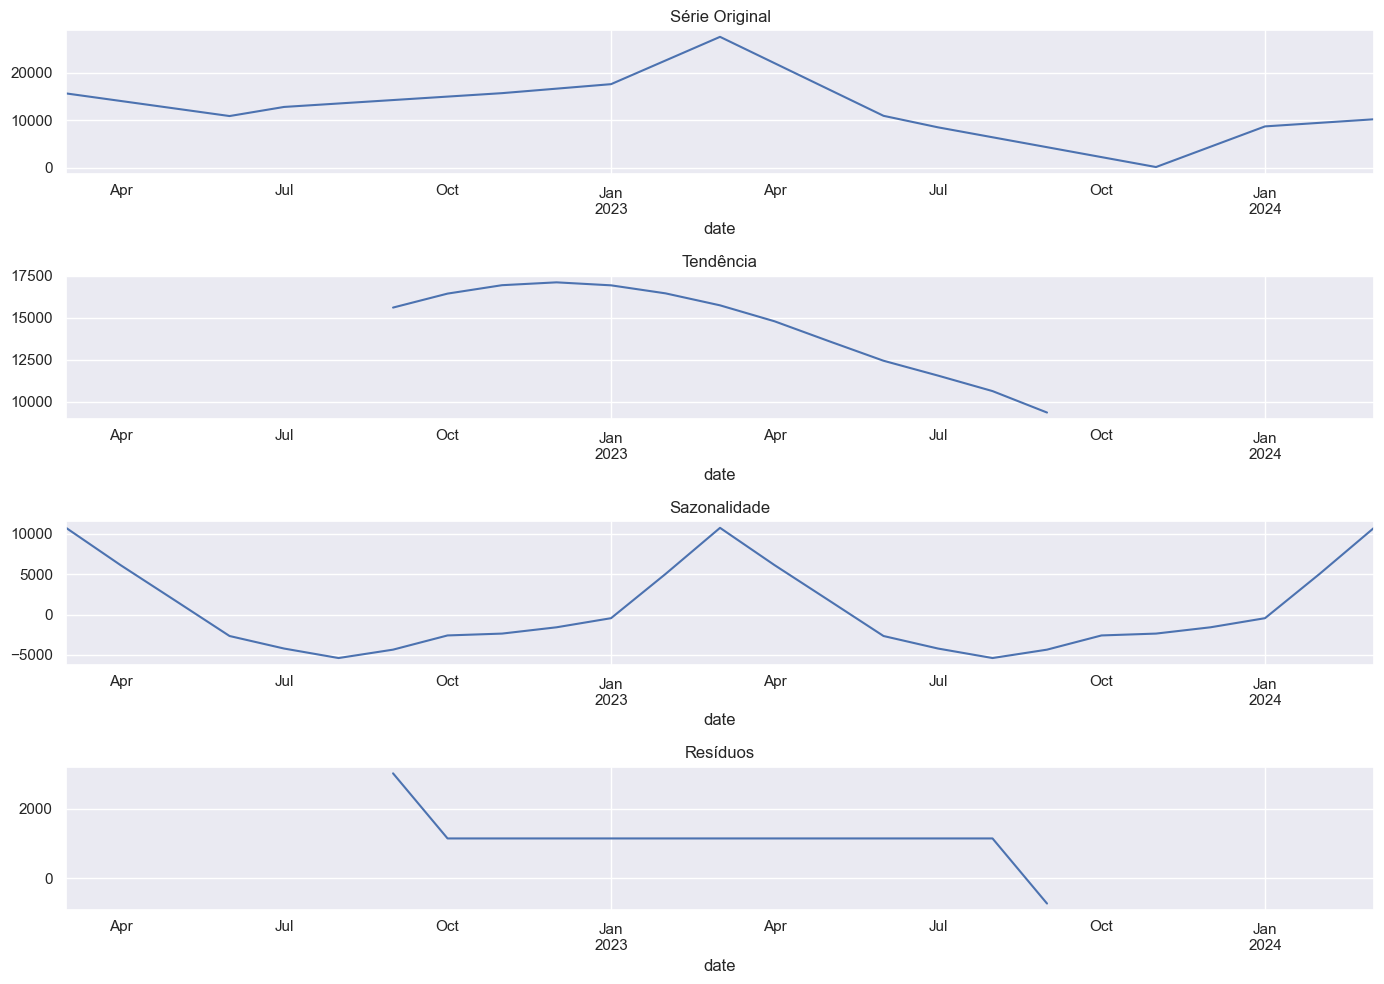

In [33]:
# Decomposição
seasonal_decompose_plot(df_ts['sales'], period=12)

#### Decomposição Sazonal

Para confirmar os padrões identificados na série temporal das vendas do **Produto A, Centro U**, realizamos uma decomposição sazonal utilizando a função `seasonal_decompose` com período s=12 (sazonalidade anual). Essa análise separa a série em três componentes: tendência, sazonalidade e resíduos, permitindo uma compreensão detalhada dos padrões existentes.

- **Série Original**: A série (`df_ts['sales']`) apresenta 25 meses (Mar/2022 a Mar/2024), com valores interpolados linearmente para preencher 56% de lacunas, variando de 100 a 27000 caixas, com um pico em Março/2023 (27000 caixas) e uma queda em Junho/2024 (10000 caixas).
- **Tendência**: Mostra um crescimento gradual até Janeiro/2023, seguido por uma queda acentuada, refletindo uma tendência de demanda crescente até o pico sazonal e subsequente redução. A tendência varia entre ~10.000 e ~17.500 caixas ao longo do período.
- **Sazonalidade**: Revela um padrão anual claro, com picos positivos em Março (aproximadamente 10.000 caixas), indicando sazonalidade típica de demanda farmacêutica no começo do ano. Os vales caem nos próximos meses, como Junho e Julho, sugerindo quedas sazonais.
- **Resíduos**: Apresentam ruído aleatório próximo de zero, com pequenas variações (até ±2.000 caixas), indicando que a decomposição capturou bem a tendência e a sazonalidade, restando apenas pequenas anomalias ou ruído. Não há padrões evidentes nos resíduos, sugerindo um ajuste razoável.

Essa decomposição confirma a sazonalidade anual (s=12), tendência crescente até Março/2023.

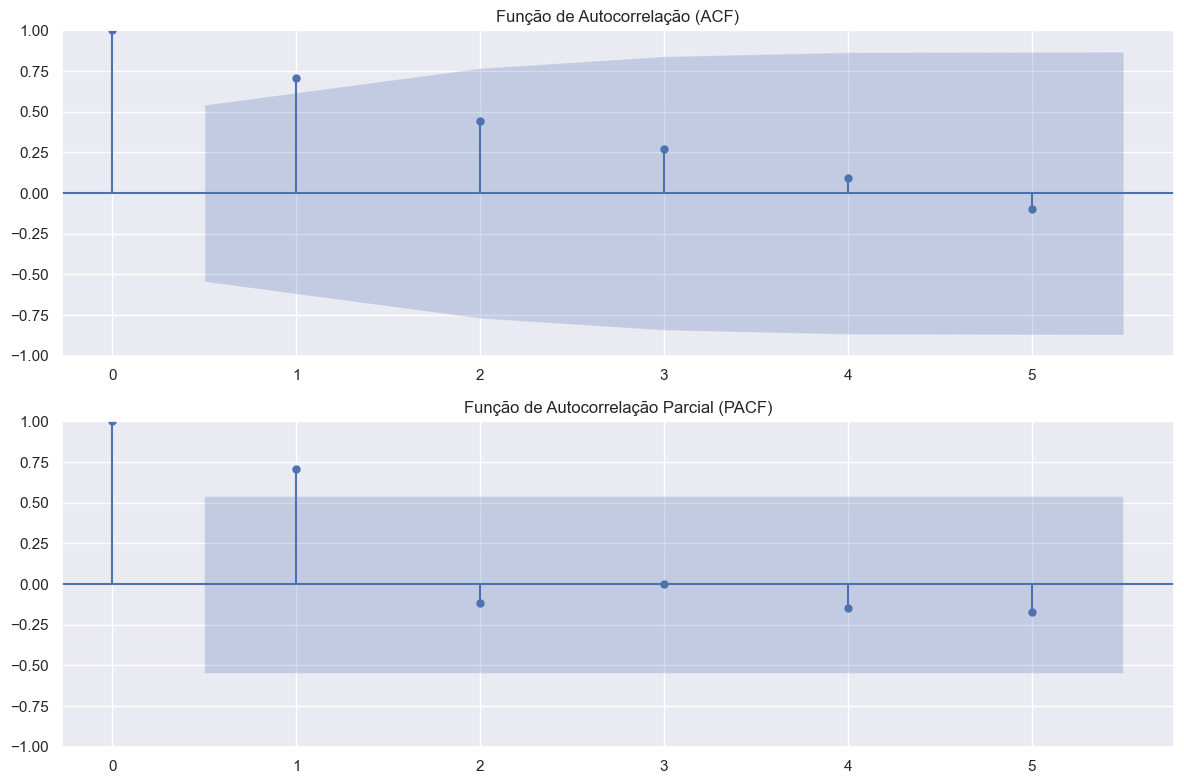

In [41]:
# Autocorrelação

plot_acf_pacf(df_ts['sales_diff_seasonal'].dropna(), lags=5)

#### Análise de Autocorrelação (ACF/PACF)

A análise das funções de autocorrelação (ACF) e autocorrelação parcial (PACF) foi realizada na série diferenciada sazonal (`df_ts['sales_diff_seasonal']`), que se mostrou estacionária após diferenciação sazonal (D=1, s=12), com 13 observações. Utilizamos lags=5 para respeitar o limite de 50% do tamanho da amostra (máximo 6 lags). O que temos então:

- **Função de Autocorrelação (ACF)**: Observa-se um pico significativo em lag 1 (autocorrelação ~0.75), indicando um componente de média móvel (MA, q=1). A partir de lag 2, as autocorrelações caem rapidamente para valores próximos de zero e dentro dos limites de confiança, sugerindo ausência de autocorrelação adicional em lags maiores. Isso indica que q=0 ou q=1 é suficiente para o componente MA.

- **Função de Autocorrelação Parcial (PACF)**: Há um pico significativo em lag 1 (autocorrelação parcial ~0.75), sugerindo um componente autoregressivo (AR, p=1). Nos lags seguintes (2 a 5), os valores estão próximos de zero e dentro dos limites de confiança, indicando ausência de AR adicional. Assim, p=1 é adequado.

- **Sazonalidade**: Devido à diferenciação sazonal (D=1, s=12), não observamos picos claros em lag 12 (limite de lags=5 impede captura direta), mas a sazonalidade **já foi tratada**, sugerindo P=0 ou P=1, e Q=0 com s=12. Sendo que P é o componente autoregressivo sazonal, Q é o componente de média móvel sazonal e S é o período sazonal, que sabemos que é 12. Q é 0 pois não temos picos significativos na ACF.

Com base nisso, sugerimos os parâmetros iniciais para o modelo SARIMA como (p=1, d=1, q=1)(P=0, D=1, Q=0, s=12), sujeito a ajustes finos na fase de modelagem. Esses parâmetros refletem a autocorrelação de curto prazo (lag 1) e a sazonalidade tratada (s=12), considerando a amostra limitada e os dados interpolados (56% de lacunas preenchidas linearmente).

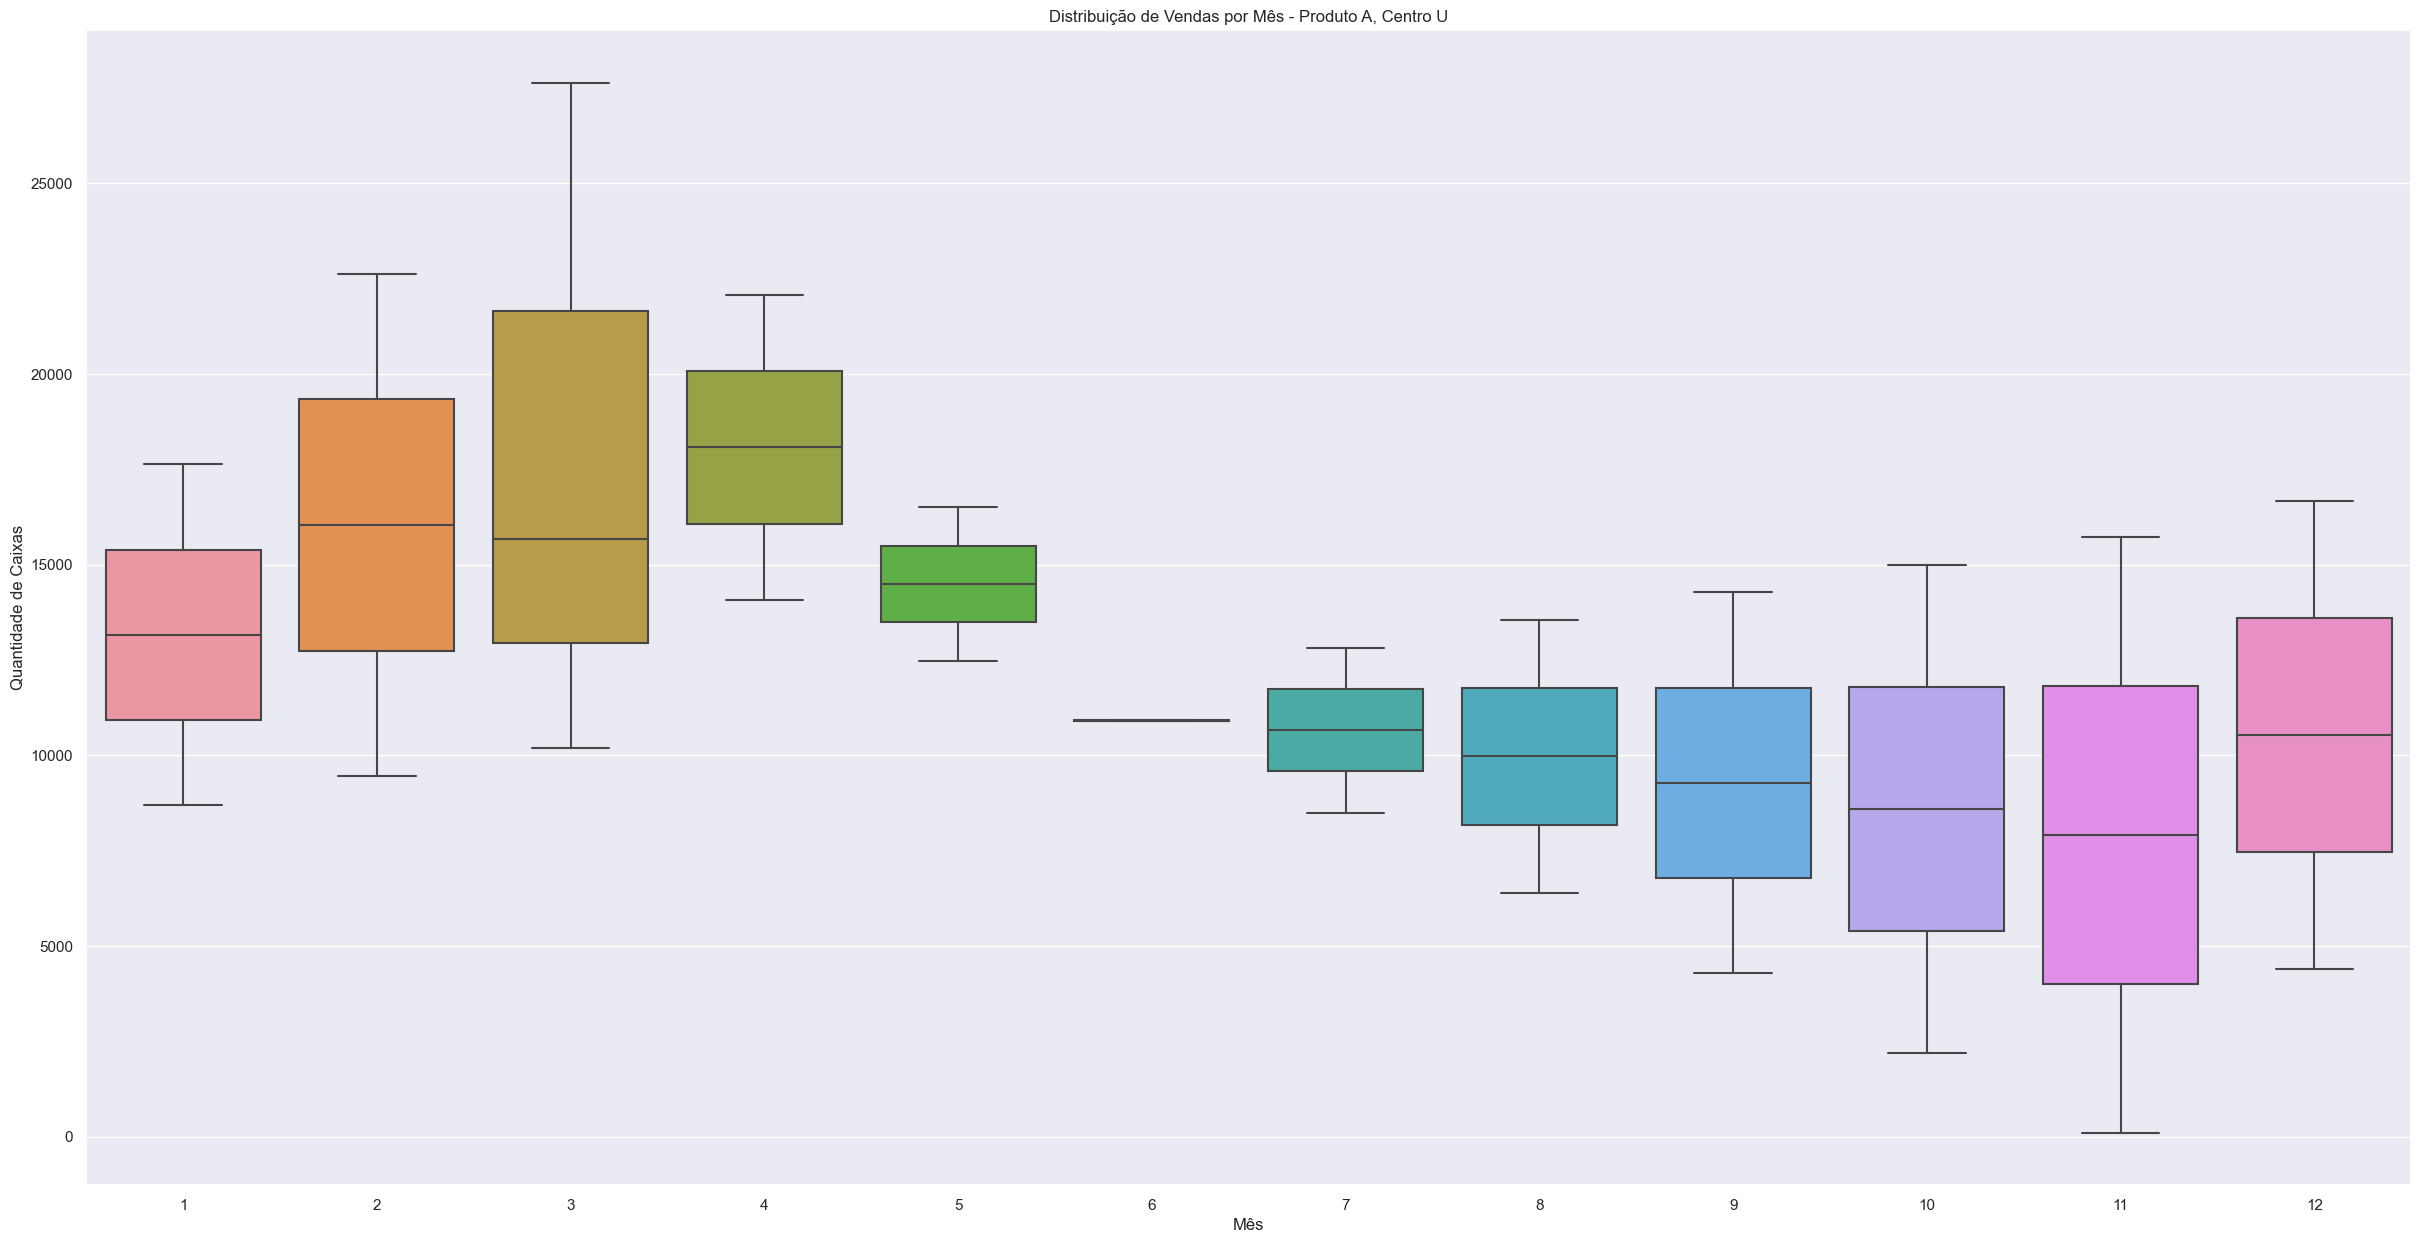

In [44]:
sns.boxplot(x=df_ts.index.month, y='sales', data=df_ts)
plt.title('Distribuição de Vendas por Mês - Produto A, Centro U')
plt.xlabel('Mês')
plt.ylabel('Quantidade de Caixas')
plt.show()

#### Análise de Sazonalidade

A visualização da distribuição mensal das vendas do **Produto A, Centro U** foi realizada por meio de um boxplot, agrupando os dados por mês ao longo dos 25 meses (Mar/2022 a Mar/2024), interpolados para preencher 56% de lacunas. Então temos que:

- **Padrão Sazonal**: Observa-se um pico claro em Março, com mediana e quartis superiores próximos de 15.000 a 20.000 caixas, indicando uma sazonalidade anual significativa, típica de demandas farmacêuticas no começo do ano. Outros meses, como Maio, Junho e Julho, mostram medianas mais baixas (abaixo de 15.000 caixas), com menos variabilidade.

- **Outliers e Anomalias**: Há outliers em Março/2023 (aproximadamente 27.000 caixas), sugerindo possíveis anomalias ou picos extremos de demanda, alinhados com o contexto de sazonalidade. Meses como Outubro e Novembro apresentam maior dispersão, mas sem outliers significativos além de Março.

- **Variabilidade**: A variabilidade (IQR - intervalo interquartil) é maior em Março, refletindo demanda volátil, enquanto meses como Junho e Agosto mostram menores dispersões, indicando estabilidade sazonal nesses meses, enquanto notamos um progressivo crescimento conforme Novembro se aproxima.

Essa análise confirma a sazonalidade anual (s=12), com picos em Março, tendência de maior demanda no começo do ano (primeiro trimeste) e possíveis anomalias em Março/2023, reforçando os resultados da decomposição sazonal e preparando a base para modelagem.

 # 4. Model Phase

 ### Funções definidas

In [63]:
# Funções de validação e métricas 
def time_series_split(data, date_column, test_size=0.2):
    data = data.sort_values(by=date_column)
    split_point = int(len(data) * (1 - test_size))
    train_data = data.iloc[:split_point].copy()
    test_data = data.iloc[split_point:].copy()
    print(f"Período de treinamento: {train_data[date_column].min()} até {train_data[date_column].max()}")
    print(f"Período de teste: {test_data[date_column].min()} até {test_data[date_column].max()}")
    return train_data, test_data

def crossval_time_series(cross_dataset, kfold, weeks, model_name, model_type, target_var, date_var, exog_vars=None, verbose=False):
    mae_list = []
    mape_list = []
    rmse_list = []
    wmape_list = []
    cross_dataset = cross_dataset.sort_values(by=date_var).reset_index(drop=True)
    for k in reversed(range(1, kfold+1)):
        if verbose:
            print(f'KFold Number: {k}')
        validation_start_date = cross_dataset[date_var].max() - timedelta(days=k*weeks*7)
        validation_end_date = cross_dataset[date_var].max() - timedelta(days=(k-1)*weeks*7)
        training = cross_dataset[cross_dataset[date_var] < validation_start_date].copy()
        validation = cross_dataset[(cross_dataset[date_var] >= validation_start_date) & 
                                  (cross_dataset[date_var] <= validation_end_date)].copy()
        if model_type.lower() == 'sarima':
            order = (1, 1, 1)
            seasonal_order = (1, 1, 1, 12)
            if exog_vars:
                model = SARIMAX(training[target_var], exog=training[exog_vars], order=order, seasonal_order=seasonal_order)
                results = model.fit(disp=False)
                y_pred = results.forecast(steps=len(validation), exog=validation[exog_vars])
            else:
                model = SARIMAX(training[target_var], order=order, seasonal_order=seasonal_order)
                results = model.fit(disp=False)
                y_pred = results.forecast(steps=len(validation))
        elif model_type.lower() == 'prophet':
            train_df = pd.DataFrame({'ds': training[date_var], 'y': training[target_var]})
            model = Prophet()
            model.fit(train_df)
            future = pd.DataFrame({'ds': validation[date_var]})
            forecast = model.predict(future)
            y_pred = forecast['yhat'].values
        y_true = validation[target_var].values
        mae = mean_absolute_error(y_true, y_pred)
        mask = y_true != 0
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if sum(mask) > 0 else np.nan
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
        mae_list.append(mae)
        mape_list.append(mape)
        rmse_list.append(rmse)
        wmape_list.append(wmape)
    return pd.DataFrame([{
        'Model Name': model_name,
        'MAE CV': f"{np.mean(mae_list):.2f} +/- {np.std(mae_list):.2f}",
        'MAPE CV': f"{np.mean(mape_list):.2f} +/- {np.std(mape_list):.2f}",
        'RMSE CV': f"{np.mean(rmse_list):.2f} +/- {np.std(rmse_list):.2f}",
        'WMAPE CV': f"{np.mean(wmape_list):.2f} +/- {np.std(wmape_list):.2f}"
    }])

def model_metrics(model_name, y_true, y_pred):
    def metric_round(metric):
        return float(np.round(metric, 4))
    # Ensure y_pred is a numpy array or pandas Series
    y_pred = np.array(y_pred) if isinstance(y_pred, list) else y_pred.values if isinstance(y_pred, pd.Series) else np.array(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if sum(mask) > 0 else np.nan
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    return pd.DataFrame([{
        'Model Name': model_name,
        'MAE': metric_round(mae),
        'MAPE': metric_round(mape),
        'RMSE': metric_round(rmse),
        'WMAPE': metric_round(wmape * 100)  # Already *100 in wmape calculation
    }])

# Funções de modelagem 
def fit_sarima(train_data, test_data, target_var, date_var, order=(1,1,1), seasonal_order=(1,1,1,12), exog_vars=None):
    y_train = train_data[target_var]
    if exog_vars:
        exog_train = train_data[exog_vars]
        exog_test = test_data[exog_vars]
        model = SARIMAX(y_train, exog=exog_train, order=order, seasonal_order=seasonal_order)
    else:
        exog_test = None
        model = SARIMAX(y_train, order=order, seasonal_order=seasonal_order)
    print("Ajustando modelo SARIMA...")
    results = model.fit(disp=False)
    print("Modelo ajustado!")
    if exog_vars:
        y_pred = results.forecast(steps=len(test_data), exog=exog_test)
    else:
        y_pred = results.forecast(steps=len(test_data))
    y_true = test_data[target_var].values
    metrics = model_metrics("SARIMA", y_true, y_pred)
    plt.figure(figsize=(12, 6))
    plt.plot(train_data[date_var], train_data[target_var], label='Treino')
    plt.plot(test_data[date_var], test_data[target_var], label='Teste (Real)')
    plt.plot(test_data[date_var], y_pred, label='Previsão', color='red')
    plt.title('Previsão SARIMA')
    plt.legend()
    plt.show()
    return results, y_pred, metrics

def fit_prophet(train_data, test_data, target_var, date_var, yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False):
    df_train = pd.DataFrame({'ds': train_data[date_var], 'y': train_data[target_var]})
    model = Prophet(yearly_seasonality=yearly_seasonality, weekly_seasonality=weekly_seasonality, daily_seasonality=daily_seasonality)
    model.fit(df_train)
    future = pd.DataFrame({'ds': test_data[date_var]})
    forecast = model.predict(future)
    y_true = test_data[target_var].values
    y_pred = forecast['yhat'].values
    metrics = model_metrics("Prophet", y_true, y_pred)
    plt.figure(figsize=(12, 6))
    plt.plot(train_data[date_var], train_data[target_var], label='Treino')
    plt.plot(test_data[date_var], test_data[target_var], label='Teste (Real)')
    plt.plot(test_data[date_var], y_pred, label='Previsão', color='red')
    plt.title('Previsão Prophet')
    plt.legend()
    plt.show()
    return model, forecast, metrics

def find_optimal_sarima_params(train_data, target_var, p_range=(0, 2), d_range=(0, 2), q_range=(0, 2), P_range=(0, 2), D_range=(0, 1), Q_range=(0, 2), s=12, exog_vars=None):
    y_train = train_data[target_var]
    if exog_vars:
        exog_train = train_data[exog_vars]
    else:
        exog_train = None
    print("Iniciando busca automática de parâmetros SARIMA...")
    auto_arima = pm.auto_arima(y_train, exogenous=exog_train, start_p=p_range[0], max_p=p_range[1], start_d=d_range[0], max_d=d_range[1], start_q=q_range[0], max_q=q_range[1], start_P=P_range[0], max_P=P_range[1], start_D=D_range[0], max_D=D_range[1], start_Q=Q_range[0], max_Q=Q_range[1], m=s, seasonal=True, error_action='ignore', suppress_warnings=True, stepwise=True, trace=True)
    print(f"Melhor ordem SARIMA: {auto_arima.order} {auto_arima.seasonal_order}")
    return auto_arima.order, auto_arima.seasonal_order


 ## Feature Engineering

 ### Data Preparation

In [56]:
df_ts.head(1)

,sales,sales_diff,sales_boxcox,sales_diff_seasonal,sales_diff_full,fourier_sin_1,fourier_cos_1,fourier_sin_2,fourier_cos_2,fourier_sin_3,fourier_cos_3
date,,,,,,,,,,,
2022-03-01,15675.0,NaN,2459.20441,NaN,NaN,1.0,6.123234e-17,1.224647e-16,-1.0,-1.0,-1.836970e-16


In [49]:
df_ts.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 25 entries, 2022-03-01 to 2024-03-01
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sales                25 non-null     float64
 1   sales_diff           24 non-null     float64
 2   sales_boxcox         25 non-null     float64
 3   sales_diff_seasonal  13 non-null     float64
 4   sales_diff_full      12 non-null     float64
dtypes: float64(5)
memory usage: 1.2 KB


In [50]:
df_ts.describe()

,sales,sales_diff,sales_boxcox,sales_diff_seasonal,sales_diff_full
count,25.00000,24.000000,25.000000,13.000000,12.000000
mean,12512.52000,-228.000000,2005.724099,-5975.307692,-2450.166667
std,6445.59872,3084.342845,867.413857,9331.524809,2778.068422
min,100.00000,-5568.666667,45.735205,-17437.000000,-4362.000000
25%,8696.00000,-2099.250000,1549.910746,-12801.250000,-4042.250000
50%,12812.00000,729.500000,2099.781802,-8935.000000,-3400.708333
75%,15730.00000,950.500000,2465.961534,47.000000,-2828.750000
max,27640.00000,5004.500000,3834.845181,11965.000000,3347.500000


In [51]:
# Fourier terms como variáveis exógenas
for order in range(1, 4):  # Ordens 1-3 para sazonalidade anual 
    df_ts[f'fourier_sin_{order}'] = np.sin(2 * np.pi * order * df_ts.index.month / 12)
    df_ts[f'fourier_cos_{order}'] = np.cos(2 * np.pi * order * df_ts.index.month / 12)
exog_vars = [col for col in df_ts.columns if 'fourier' in col]
print(f"Variáveis exógenas adicionadas: {exog_vars}")


Variáveis exógenas adicionadas: ['fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2', 'fourier_sin_3', 'fourier_cos_3']


In [52]:
df_ts.head()

,sales,sales_diff,sales_boxcox,sales_diff_seasonal,sales_diff_full,fourier_sin_1,fourier_cos_1,fourier_sin_2,fourier_cos_2,fourier_sin_3,fourier_cos_3
date,,,,,,,,,,,
2022-03-01,15675.0,NaN,2459.204410,NaN,NaN,1.000000e+00,6.123234e-17,1.224647e-16,-1.0,-1.000000e+00,-1.836970e-16
2022-04-01,14079.0,-1596.0,2260.788319,NaN,NaN,8.660254e-01,-5.000000e-01,-8.660254e-01,-0.5,-2.449294e-16,1.000000e+00
2022-05-01,12483.0,-1596.0,2057.418464,NaN,NaN,5.000000e-01,-8.660254e-01,-8.660254e-01,0.5,1.000000e+00,1.194340e-15
2022-06-01,10887.0,-1596.0,1848.309127,NaN,NaN,1.224647e-16,-1.000000e+00,-2.449294e-16,1.0,3.673940e-16,-1.000000e+00
2022-07-01,12812.0,1925.0,2099.781802,NaN,NaN,-5.000000e-01,-8.660254e-01,8.660254e-01,0.5,-1.000000e+00,-4.286264e-16


As datas como index da tabela estão nos causando problemas nas funções de treinamento, então voltamos aqui para transferir o index de volta a uma coluna normal. Solução mais simples e não afeta o modelo.

In [ ]:
df_ts = df_ts.reset_index()

In [58]:
df_ts.head()

,date,sales,sales_diff,sales_boxcox,sales_diff_seasonal,sales_diff_full,fourier_sin_1,fourier_cos_1,fourier_sin_2,fourier_cos_2,fourier_sin_3,fourier_cos_3
0,2022-03-01,15675.0,NaN,2459.204410,NaN,NaN,1.000000e+00,6.123234e-17,1.224647e-16,-1.0,-1.000000e+00,-1.836970e-16
1,2022-04-01,14079.0,-1596.0,2260.788319,NaN,NaN,8.660254e-01,-5.000000e-01,-8.660254e-01,-0.5,-2.449294e-16,1.000000e+00
2,2022-05-01,12483.0,-1596.0,2057.418464,NaN,NaN,5.000000e-01,-8.660254e-01,-8.660254e-01,0.5,1.000000e+00,1.194340e-15
3,2022-06-01,10887.0,-1596.0,1848.309127,NaN,NaN,1.224647e-16,-1.000000e+00,-2.449294e-16,1.0,3.673940e-16,-1.000000e+00
4,2022-07-01,12812.0,1925.0,2099.781802,NaN,NaN,-5.000000e-01,-8.660254e-01,8.660254e-01,0.5,-1.000000e+00,-4.286264e-16


 ### Feature Selection

In [53]:
# Usaremos todas as variáveis Fourier para SARIMAX
print(f"Variáveis exógenas selecionadas: {exog_vars}")


Variáveis exógenas selecionadas: ['fourier_sin_1', 'fourier_cos_1', 'fourier_sin_2', 'fourier_cos_2', 'fourier_sin_3', 'fourier_cos_3']


 ## Model Building

 ### Train-Test Splitting

In [61]:
train, test = time_series_split(df_ts, 'date', test_size=0.2)


Período de treinamento: 2022-03-01 00:00:00 até 2023-10-01 00:00:00
Período de teste: 2023-11-01 00:00:00 até 2024-03-01 00:00:00


 ### Model Selection

 #### Baseline Training

In [64]:
baseline_pred = train['sales'].mean()
baseline_metrics = model_metrics("Baseline", test['sales'], [baseline_pred] * len(test))
print(baseline_metrics)


  Model Name       MAE       MAPE       RMSE       WMAPE
0   Baseline  7429.025  2852.5848  8349.1392  11308.7011


 #### Cross Validation Training

In [65]:
sarima_cv = crossval_time_series(df_ts, kfold=3, weeks=4, model_name='SARIMA', model_type='sarima', target_var='sales', date_var='date', exog_vars=exog_vars)
prophet_cv = crossval_time_series(df_ts, kfold=3, weeks=4, model_name='Prophet', model_type='prophet', target_var='sales', date_var='date')
print(sarima_cv)
print(prophet_cv)


AttributeError: 'Prophet' object has no attribute 'stan_backend'

 #### Models Performance

In [ ]:
sarima_results, sarima_pred, sarima_metrics = fit_sarima(train, test, 'sales', 'date', exog_vars=exog_vars)
prophet_model, prophet_forecast, prophet_metrics = fit_prophet(train, test, 'sales', 'date')


 ## Model Evaluation

 ### Model Hyperparameter Fine Tuning

In [ ]:
order, seasonal_order = find_optimal_sarima_params(train, 'sales', exog_vars=exog_vars)


 ### Metrics Interpretation

 #### Business Metrics

 "WMAPE é a métrica principal, pois pondera erros pelo volume, essencial para estoque. RMSE destaca outliers relevantes."

 #### Model Metrics

In [ ]:
print(pd.concat([baseline_metrics, sarima_metrics, prophet_metrics]))


 # 5. Deployment Phase

 ## Visualization and Dashboard

 ### Performance Assessment

 ### Model Performance

 #### Baseline vs Model Performance

In [ ]:
# <graph comparing baseline, SARIMA, Prophet here>


 #### Model Performance in Business

In [ ]:
# <graph showing business impact here>


 ### Business Performance Gain

 "Redução de custos estimada em X% com estoque otimizado."

 ## API Development

 ### Prediction Class

 ### API Handler

 ### API Tester

 ## Web App

 ### Frontend

 "API Telegram para acesso via celular planejada como próxima etapa."